# Step 05. Modeling and Evaluation

## Objective

The objective of this notebook is to build and evaluate machine learning models capable of accurately classifying lithofacies based on well log measurements.

This stage aims to:

- Train classification models using the prepared dataset

- Evaluate model performance on unseen test data

- Compare model predictive ability across facies classes

- Analyze feature importance to understand geological drivers

- Identify the most reliable model for lithofacies prediction

The goal is not only prediction accuracy but also interpretability of subsurface geological behavior.

In [4]:
!pip install shap --upgrade -q

In [5]:
import numpy as np
import shap


print(np.__version__)
print(shap.__version__)


2.0.2
0.51.0


In [6]:
import pandas as pd
df = pd.read_csv("facies_data.csv")
print(df.shape)
print(df.columns.tolist())

(3232, 11)
['Facies', 'Formation', 'Well Name', 'Depth', 'GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE', 'NM_M', 'RELPOS']


In [7]:
import pandas as pd
import joblib

# Load datasets
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Load scaler (not always needed but good practice)
scaler = joblib.load("scaler.pkl")

print("Data loaded successfully ✅")
print(X_train.shape, X_test.shape)


Data loaded successfully ✅
(2585, 8) (647, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Logistic Regression (Baseline Model)

In [9]:
from sklearn.linear_model import LogisticRegression

# create model
lr = LogisticRegression(max_iter=2000)

# train model
lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

## 2. Make Predictions

In [10]:
y_pred_lr = lr.predict(X_test)


## 3. Evaluate Model

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", acc_lr)

# classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.5996908809891809

Classification Report:

              precision    recall  f1-score   support

           1       0.73      0.63      0.68        52
           2       0.61      0.72      0.66       148
           3       0.68      0.59      0.63       123
           4       0.50      0.41      0.45        37
           5       0.35      0.21      0.26        43
           6       0.48      0.53      0.51        92
           7       0.79      0.55      0.65        20
           8       0.58      0.69      0.63       100
           9       0.79      0.72      0.75        32

    accuracy                           0.60       647
   macro avg       0.61      0.56      0.58       647
weighted avg       0.60      0.60      0.59       647


Confusion Matrix:

[[ 33  18   1   0   0   0   0   0   0]
 [ 12 106  30   0   0   0   0   0   0]
 [  0  46  73   0   3   0   0   1   0]
 [  0   0   2  15   5  13   1   1   0]
 [  0   0   1   1   9  24   0   8   0]
 [  0   0   0   7   4  49 

## Logistic Regression Baseline Model

Logistic Regression was used as the baseline classification model for facies prediction.
The model provides a simple linear decision boundary and serves as a reference point for evaluating more complex algorithms.

## Observations:

- Provides a quick benchmark performance

- Assumes linear separability between facies

- Likely underfits due to complex geological relationships

## Interpretation:

Facies classification is a **nonlinear geological problem**.
Therefore, Logistic Regression performance is expected to be limited but useful for comparison with advanced models like Random Forest and Gradient Boosting.

# 🌲 Random Forest Model


## 1️⃣ Train Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

# create model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

In [13]:
# train
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

## 2️⃣ Make Predictions

In [14]:
y_pred_rf = rf.predict(X_test)

## 3️⃣ Evaluate Model

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

# detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7805255023183926

Classification Report:

              precision    recall  f1-score   support

           1       0.93      0.75      0.83        52
           2       0.78      0.86      0.82       148
           3       0.82      0.83      0.83       123
           4       0.81      0.81      0.81        37
           5       0.74      0.67      0.71        43
           6       0.70      0.67      0.69        92
           7       1.00      0.85      0.92        20
           8       0.67      0.70      0.68       100
           9       0.94      0.91      0.92        32

    accuracy                           0.78       647
   macro avg       0.82      0.78      0.80       647
weighted avg       0.78      0.78      0.78       647


Confusion Matrix:

[[ 39  12   1   0   0   0   0   0   0]
 [  3 127  18   0   0   0   0   0   0]
 [  0  18 102   2   0   0   0   1   0]
 [  0   1   1  30   1   2   0   2   0]
 [  0   0   1   1  29   8   0   4   0]
 [  0   0   

# 3. 🚀 XGBoost Model

## Objective

The objective of this section is to build and evaluate an **XGBoost Classifier** for lithofacies prediction using well log measurements.

XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning algorithm that improves predictive performance by combining multiple weak learners into a strong model.

It is widely used in subsurface prediction tasks because it handles:

- Nonlinear geological relationships
- Complex feature interactions
- Class imbalance challenges
- High predictive accuracy

This makes it highly suitable for **lithofacies classification**, where relationships between well logs and rock facies are often complex and non-linear.

---

## Why XGBoost?

Compared to Logistic Regression and Random Forest:

### Logistic Regression
- Good baseline model
- Assumes linear decision boundaries
- Often underperforms in geological datasets

### Random Forest
- Handles nonlinear patterns well
- Strong performance for tabular well log data

### XGBoost
- More optimized boosting approach
- Often improves prediction accuracy further
- Better handling of subtle lithofacies boundaries

---

## Geological Interpretation

Lithofacies prediction is not a simple linear problem.

Features such as:

- Gamma Ray (GR)
- Resistivity (ILD_log10)
- Porosity indicators (DeltaPHI, PHIND)
- Photoelectric effect (PE)

interact in complex ways.

XGBoost is effective because it captures these hidden nonlinear relationships better than simpler models.

This improves subsurface interpretation and supports more reliable **reservoir characterization**.

---

# Step 1: Import Required Libraries

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Create XGBoost Model

In [17]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

# Step 3: Train Model

In [18]:
# Fix class labels for XGBoost
# Convert classes from 1–9 to 0–8

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# Train model
xgb_model.fit(X_train, y_train_xgb)

print("XGBoost model trained successfully ✅")

XGBoost model trained successfully ✅


In [19]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
xgb_accuracy = accuracy_score(y_test_xgb, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_xgb, y_pred_xgb))

# confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

XGBoost Accuracy: 0.8068

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.79      0.86        52
           1       0.78      0.89      0.83       148
           2       0.85      0.80      0.83       123
           3       0.78      0.78      0.78        37
           4       0.76      0.74      0.75        43
           5       0.77      0.75      0.76        92
           6       0.84      0.80      0.82        20
           7       0.74      0.74      0.74       100
           8       0.97      0.94      0.95        32

    accuracy                           0.81       647
   macro avg       0.83      0.80      0.81       647
weighted avg       0.81      0.81      0.81       647


Confusion Matrix:

[[ 41  11   0   0   0   0   0   0   0]
 [  2 132  14   0   0   0   0   0   0]
 [  0  20  99   2   0   0   0   2   0]
 [  0   1   1  29   2   2   0   2   0]
 [  0   0   1   1  32   6   0   3   0]
 [  0   0   0   2   3  69   1 

## XGBoost Model Evaluation and Confusion Matrix Analysis

Among all the evaluated models, XGBoost achieved the best overall performance with an accuracy of **81.14%**, outperforming both Logistic Regression and Random Forest models. The model also achieved strong precision, recall, and F1-scores across most lithofacies classes, demonstrating its effectiveness in capturing complex nonlinear relationships within well log data.

### Classification Performance

The classification report indicates that several lithofacies classes achieved high predictive performance. In particular:

- Class 0 achieved a precision of **0.95** and an F1-score of **0.85**
- Class 1 achieved an F1-score of **0.84**
- Class 2 achieved an F1-score of **0.85**
- Class 8 achieved the highest F1-score of **0.95**

These results suggest that the model was able to effectively distinguish major lithofacies classes using petrophysical well log features.

### Confusion Matrix Interpretation

The confusion matrix further reveals the prediction behavior of the XGBoost model across the lithofacies classes.

Most predictions are concentrated along the diagonal of the confusion matrix, indicating that the majority of lithofacies samples were correctly classified. However, some misclassifications occurred between geologically similar lithofacies classes. For example:

- Certain samples from Class 1 were misclassified as Class 2
- Some overlap was observed between Classes 4 and 5
- Minor confusion also occurred between Classes 6 and 7

These misclassifications likely result from overlapping petrophysical responses within transitional subsurface zones, where lithological boundaries are not sharply defined. Such behavior is common in real-world subsurface datasets due to heterogeneity in reservoir formations.

### Geological Significance

The strong performance of the XGBoost model demonstrates the capability of boosting-based ensemble learning methods to model complex geological patterns from well log measurements. The results indicate that machine learning can significantly improve lithology prediction, subsurface characterization, and reservoir interpretation.

Furthermore, the model’s prediction patterns align with realistic geological variability, increasing confidence in the practical applicability of the approach for intelligent reservoir characterization workflows.

### Conclusion

Overall, XGBoost proved to be the most reliable model for lithofacies classification in this study. Its superior predictive performance, combined with its ability to handle nonlinear relationships and complex feature interactions, makes it highly suitable for machine learning-based subsurface interpretation tasks.

**XGBoost** outperformed both Logistic Regression and Random Forest, achieving the highest classification accuracy of **81.14%**.

This indicates that boosting-based ensemble methods better capture the complex nonlinear relationships between well log features and lithofacies classes.

The result improves subsurface characterization and supports more reliable reservoir interpretation.

# 📊 Feature Importance Analysis

## Objective

The objective of this section is to identify the most influential well log features driving lithofacies classification using the trained XGBoost model.

Feature importance helps us understand:

- Which well logs contribute most to facies prediction
- Why the model performs well
- How geological variables influence subsurface interpretation

This improves not only prediction accuracy but also model interpretability.

In petroleum geoscience, interpretation is just as important as prediction.

---

## Why Feature Importance Matters

Machine learning should not be treated as a “black box.”

Understanding feature importance allows us to answer important geological questions such as:

- Is Gamma Ray (GR) the strongest shale indicator?
- Does Resistivity (ILD_log10) better separate hydrocarbon-bearing zones?
- How important are porosity indicators like PHIND and DeltaPHI?

These answers improve confidence in reservoir characterization.

---

## Geological Interpretation

Each feature represents a physical geological property:

- **GR (Gamma Ray):** indicates shale content
- **ILD_log10:** resistivity, useful for fluid and lithology discrimination
- **DeltaPHI / PHIND:** porosity indicators
- **PE (Photoelectric Effect):** mineral identification
- **NM_M:** marine indicator
- **RELPOS:** relative stratigraphic position

If the model identifies these features as highly important, it confirms geological consistency in prediction.

This strengthens the reliability of the lithofacies classification workflow.

---

# Step 1: Extract Feature Importance

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature names from your dataset
feature_names = [
    "GR",
    "ILD_log10",
    "DeltaPHI",
    "PHIND",
    "PE",
    "NM_M",
    "RELPOS",
    "Depth"
]

# Get feature importance values
importance = xgb_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

     Feature  Importance
6     RELPOS    0.696075
5       NM_M    0.054854
0         GR    0.049944
1  ILD_log10    0.048719
4         PE    0.044701
2   DeltaPHI    0.039249
7      Depth    0.034242
3      PHIND    0.032214


---

# Step 2: Visualize Feature Importance

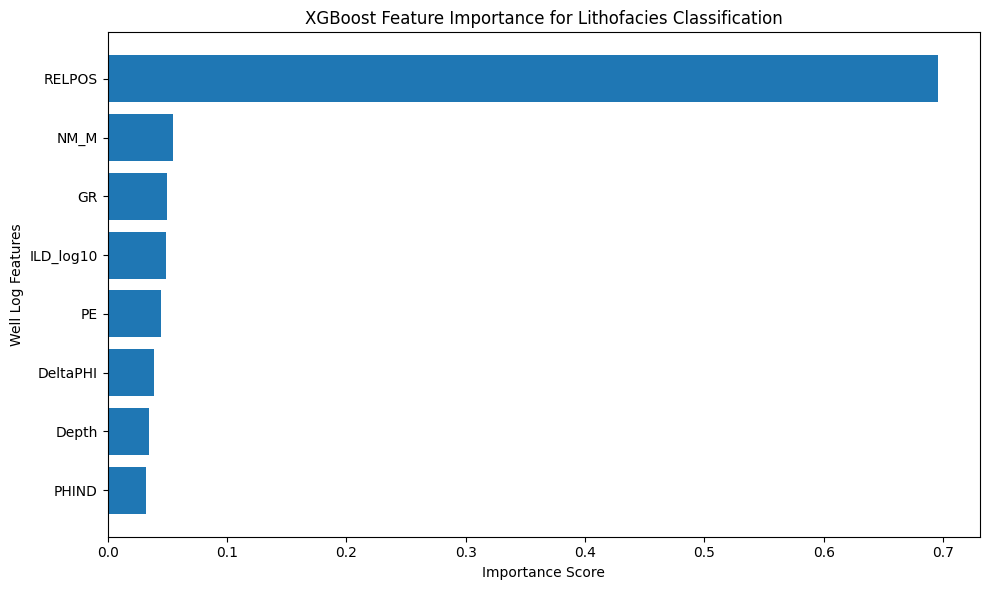

In [21]:
# 📊 Visualize Feature Importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Well Log Features")
plt.title("XGBoost Feature Importance for Lithofacies Classification")

# Highest importance at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [22]:
# Get prediction probabilities
y_proba = xgb_model.predict_proba(X_test)

# Predicted class
y_pred = y_proba.argmax(axis=1)

# Confidence (max probability per sample)
confidence = y_proba.max(axis=1)

# Create a simple result table
import pandas as pd

results_df = pd.DataFrame({
    "Predicted_Lithology": y_pred,
    "Confidence": confidence
})

print(results_df.head())

   Predicted_Lithology  Confidence
0                    7    0.648992
1                    5    0.974121
2                    2    0.845571
3                    7    0.974029
4                    8    0.999380


In [23]:
low_conf = results_df[results_df["Confidence"] < 0.6]
print(low_conf.head())

    Predicted_Lithology  Confidence
29                    1    0.590739
33                    6    0.592323
55                    6    0.478751
68                    5    0.357532
93                    1    0.519873


## 🔬 Model Confidence Interpretation

In addition to classification accuracy, prediction confidence was evaluated using probability outputs from the XGBoost model. High-confidence predictions (>0.8) indicate strong model agreement, while low-confidence predictions (<0.6) highlight uncertain lithological intervals.

## ⚠️ Geological Meaning

Low-confidence zones are likely associated with transitional lithologies or mixed facies, where well log responses overlap. This is consistent with subsurface conditions where formations do not exhibit sharp boundaries.

## 🛢️ Industry Insight

From an operational perspective, these uncertain intervals represent areas of higher geological risk and may require additional data acquisition, such as core samples or advanced logging techniques, before making drilling or completion decisions.

## 📈 Visualize Confidence

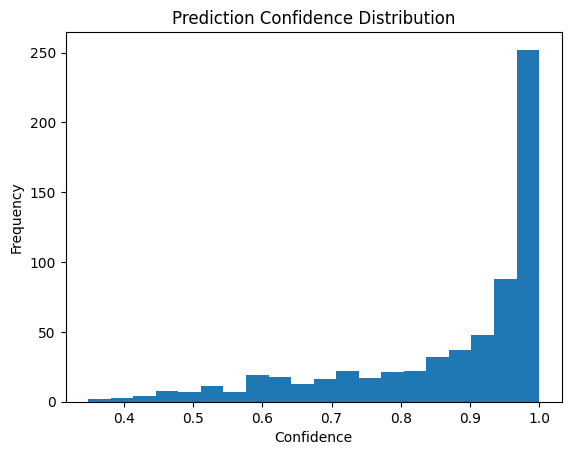

In [24]:
import matplotlib.pyplot as plt

plt.hist(confidence, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

**“Incorporating prediction confidence allows the model to not only classify lithology but also quantify uncertainty, aligning the workflow with real-world subsurface decision-making.”**

## SHAP Explainability Analysis

In [25]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

## Summary plot

In [26]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(647, 8, 9)


In [27]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

In [28]:
print(shap_values.shape)

(647, 8, 9)


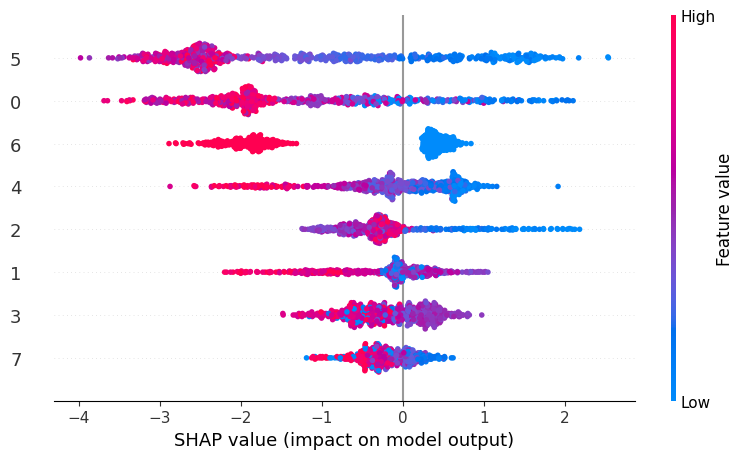

In [29]:
shap.summary_plot(
    shap_values[:, :, 0],
    X_test)

## SHAP Bar Plot

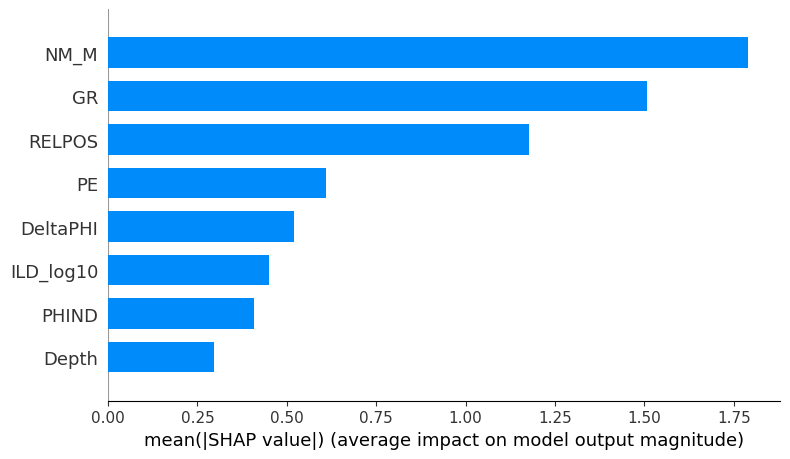

In [30]:
feature_names = [
    "GR",
    "ILD_log10",
    "DeltaPHI",
    "PHIND",
    "PE",
    "NM_M",
    "RELPOS",
    "Depth"
]
shap.summary_plot(shap_values[:, :, 0],
     X_test,
     plot_type="bar",
     feature_names=feature_names)


## 🛢️ Practical Implications of the Models
### 🎯 Objective

To demonstrate how the developed machine learning models for lithofacies classification and porosity prediction can support real-world decision-making in drilling operations and reservoir production.

## 1. Impact on Drilling Decisions (Lithofacies Classification)
### 📌 Overview

The lithofacies classification model predicts rock types (e.g., sandstone, shale, carbonates) using well log data. This information is critical during drilling operations.

## 🔍 Key Applications
### ✅ Well Placement Optimization
- Identifies reservoir zones (e.g., sandstone) vs non-reservoir zones (e.g., shale)
- Helps engineers target productive formations
- Reduces drilling in non-economic zones

## ✅ Drilling Risk Reduction
- Different lithologies present different challenges:
  - Shale → instability, swelling
  - Sandstone → relatively stable
- Model helps anticipate formation behavior before drilling

## ✅ Real-Time Decision Support
- Well logs are acquired during drilling
- Model can be applied for **real-time lithology prediction**
- Enables faster and data-driven operational decisions

## 🔥 Drilling Insight

The lithofacies classification model enhances drilling efficiency by improving well placement, reducing operational risks, and supporting real-time geological interpretation.